In [1]:
library(ggplot2)
library(dplyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




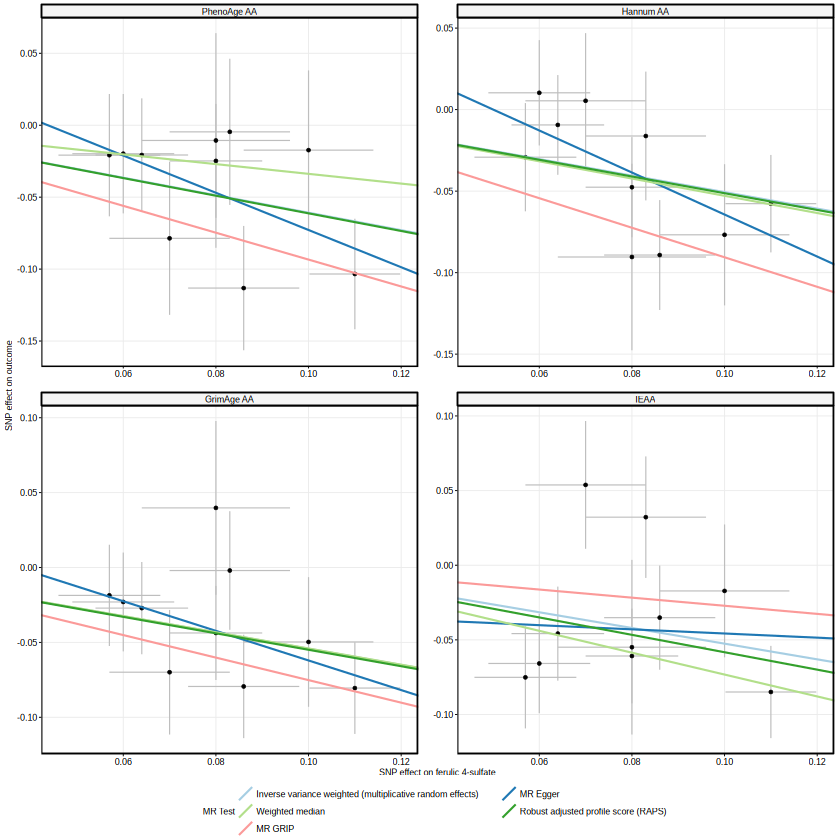

In [3]:
target_config_dir <- "/vol/projects/yzhang/500FG_aging/output/16_MR/ferulic_4_sulfate_p1e-06_kb10000_r20.5_kb10000_r20.5"
combined_output_dir <- file.path(target_config_dir, "MR_combined_results")
dir.create(combined_output_dir, showWarnings = FALSE, recursive = TRUE)
outcome_order <- c("PhenoAge_AA", "Hannum_AA", "GrimAge_AA", "IEAA")
outcome_labels <- c(
  PhenoAge_AA = "PhenoAge AA",
  Hannum_AA   = "Hannum AA",
  GrimAge_AA  = "GrimAge AA",
  IEAA        = "IEAA"
)
tsmr_cols <- c(
  "#a6cee3", "#1f78b4", "#b2df8a", "#33a02c", "#fb9a99", "#e31a1c",
  "#fdbf6f", "#ff7f00", "#cab2d6", "#6a3d9a", "#ffff99", "#b15928"
)
mr_dirs <- list.dirs(target_config_dir, full.names = TRUE, recursive = FALSE)
mr_dirs <- mr_dirs[grepl("/MR_output_", mr_dirs)]
snp_list  <- list()
line_list <- list()
for (d in mr_dirs) {
  outcome_name <- sub("^MR_output_", "", basename(d))
  hf <- file.path(d, "harmonised_data_with_F.csv")
  mf <- file.path(d, "MR_all_methods.csv")
  if (!file.exists(hf)) stop("Missing: ", hf)
  if (!file.exists(mf)) stop("Missing: ", mf, " — not re-running mr()")
  dat    <- read.csv(hf, stringsAsFactors = FALSE)
  mr_res <- read.csv(mf, stringsAsFactors = FALSE)
  num_d <- intersect(c("beta.exposure", "beta.outcome", "se.exposure", "se.outcome"), names(dat))
  for (cc in num_d) dat[[cc]] <- as.numeric(dat[[cc]])
  if ("b" %in% names(mr_res)) mr_res$b <- as.numeric(mr_res$b)
  if ("mr_keep" %in% names(dat)) {
    dat <- dat[dat$mr_keep %in% c(TRUE, "TRUE", 1), , drop = FALSE]
  }
  index <- dat$beta.exposure < 0
  dat$beta.exposure[index] <- dat$beta.exposure[index] * -1
  dat$beta.outcome[index]  <- dat$beta.outcome[index]  * -1
  mr_res$a <- 0
  if ("MR Egger" %in% mr_res$method) {
    r <- lm(beta.outcome ~ beta.exposure, data = dat, weights = 1 / dat$se.outcome^2)
    mr_res$a[mr_res$method == "MR Egger"] <- unname(coef(r)[1])
  }
  if ("MR Egger (bootstrap)" %in% mr_res$method) {
    r <- lm(beta.outcome ~ beta.exposure, data = dat, weights = 1 / dat$se.outcome^2)
    mr_res$a[mr_res$method == "MR Egger (bootstrap)"] <- unname(coef(r)[1])
  }
  dat$outcome_name    <- outcome_name
  mr_res$outcome_name <- outcome_name
  snp_list[[outcome_name]]  <- dat
  line_list[[outcome_name]] <- mr_res
}
present <- outcome_order[outcome_order %in% names(snp_list)]
snp_df  <- bind_rows(snp_list[present])
line_df <- bind_rows(line_list[present])
snp_df$outcome_lab  <- factor(outcome_labels[snp_df$outcome_name],
                              levels = unname(outcome_labels[present]))
line_df$outcome_lab <- factor(outcome_labels[line_df$outcome_name],
                              levels = unname(outcome_labels[present]))
method_levels <- unique(unlist(lapply(line_list[present], function(x) x$method), use.names = FALSE))
line_df$method <- factor(line_df$method, levels = method_levels)
pal <- tsmr_cols[seq_along(method_levels)]
names(pal) <- method_levels
p_scatter <- ggplot(snp_df, aes(x = beta.exposure, y = beta.outcome)) +
  geom_errorbar(
    aes(ymin = beta.outcome - se.outcome, ymax = beta.outcome + se.outcome),
    colour = "grey", width = 0, linewidth = 0.25
  ) +
  geom_errorbarh(
    aes(xmin = beta.exposure - se.exposure, xmax = beta.exposure + se.exposure),
    colour = "grey", width = 0, linewidth = 0.25
  ) +
  geom_point(size = 0.7, stroke = 0.2) +
  geom_abline(
    data = line_df,
    aes(intercept = a, slope = b, colour = method),
    linewidth = 0.45, show.legend = TRUE
  ) +
  scale_colour_manual(values = pal, drop = FALSE) +
  facet_wrap(~ outcome_lab, scales = "free", ncol = 2) +
  labs(
    colour = "MR Test",
    x = "SNP effect on ferulic 4-sulfate",
    y = "SNP effect on outcome"
  ) +
  theme_bw(base_size = 5) +
  theme(
    plot.background   = element_rect(fill = "white", colour = NA),
    panel.background  = element_rect(fill = "white", colour = NA),
    panel.grid.major  = element_line(colour = "grey92", linewidth = 0.2),
    panel.grid.minor  = element_blank(),
    axis.text         = element_text(size = 5, colour = "black"),
    axis.title        = element_text(size = 5, colour = "black"),
    axis.ticks        = element_line(linewidth = 0.2, colour = "black"),
    axis.ticks.length = unit(0.05, "cm"),
    panel.border      = element_rect(colour = "black", fill = NA, linewidth = 0.4),
    strip.clip        = "off",
    strip.text        = element_text(size = 5, colour = "black",
    margin            = margin(1.2, 1.2, 1.2, 1.2)),
    strip.background  = element_rect(fill = "grey96", colour = "black", linewidth = 0.4),
    legend.position   = "bottom",
    legend.direction  = "horizontal",
    legend.title      = element_text(size = 5, colour = "black"),
    legend.text       = element_text(size = 5, colour = "black"),
    legend.key.size   = unit(0.28, "cm"),
    legend.spacing.x  = unit(0.12, "cm"),
    legend.margin     = margin(t = 1, b = 0),
    panel.spacing     = unit(0.6, "lines"),
    plot.margin       = margin(3, 4, 3, 3)
  ) +
  guides(colour = guide_legend(ncol = 2, byrow = TRUE))
width_mm  <- 180
height_mm <- 180 * (8 / 10) + 18
ggsave(
  filename = file.path(combined_output_dir, "combined_scatter_plot.pdf"),
  plot     = p_scatter,
  width    = width_mm,
  height   = height_mm,
  units    = "mm",
  dpi      = 300,
  bg       = "white"
)
print(p_scatter)
